# **Modelo de previsão de leads propensos a realizar**

# **a compra de um veículo**

## **Objetivo**

#### Aplicar o modelo XGBoost e analisar sua performance em uma base de leads de clientes de uma loja automobilística a fim de prever aqueles indivíduos mais propensos a uma compra de veículos.

#### A base de dados possui características adequadas para um problema de classificação binária, com a variável target indicando a realização ou não de compra.

#### o modelo busca apoiar o time de negócios, encontrando os leads mais produtivos e aumentando a taxa de conversão e faturamento da organização.

## **Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import sys
from pathlib import Path

from pathlib import Path
from ydata_profiling import ProfileReport
from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV
    
)
from sklearn.linear_model import LogisticRegression
from xgboost import(
    XGBClassifier,
    callback
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    classification_report,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay
)

c:\Users\rikrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Base de dados**

In [2]:
sys.path.append(str(Path().resolve().parent))

from src.data.load_data import load_data

df = load_data('CARRO_CLIENTES.csv', subfolder= 'original')

df.head()

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


#### o dataset possui **1.000 registros** e **5 variáveis**, sendo:

#### 'User ID', que será removida pois não contem nenhuma informação relevante para o modelo.

#### 'Gender', variável categórica que poderá ser dummificada para se tornar uma variável numérica.

#### o dataset também possui variáveis geográficas numéricas:

#### 'Age' que contém a idade dos clientes.

#### e 'AnnualSalary' que contém a renda anual dos clientes.

### **'Purchased' é a variável-target binária que o modelo tentará prever, onde 0 são não compradores e 1 compradores.**

In [4]:
# verificando valores duplicados na base
df.duplicated().sum()

np.int64(0)

#### O dataset não possui valores nulos, 

#### nem valores duplicados.

#### nessa etapa, será removida a coluna 'user ID' e transformada a coluna 'Gender' em numérica para ser utilizada na análise exploratória

In [5]:
from src.features.build_features import build_features

df = build_features(df)

## **Validação dos tratamentos**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Gender        1000 non-null   int64
 1   Age           1000 non-null   int64
 2   AnnualSalary  1000 non-null   int64
 3   Purchased     1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB


#### A base de dados agora possui 4 variáveis numéricas que serão exploradas na próxima etapa.

# **Análise exploratória (EDA)**

## **Análise estatística descritiva**

In [7]:
df.describe()

,Gender,Age,AnnualSalary,Purchased
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.484000,40.106000,72689.000000,0.402000
std,0.499994,10.707073,34488.341867,0.490547
min,0.000000,18.000000,15000.000000,0.000000
25%,0.000000,32.000000,46375.000000,0.000000
50%,0.000000,40.000000,72000.000000,0.000000
75%,1.000000,48.000000,90000.000000,1.000000
max,1.000000,63.000000,152500.000000,1.000000


#### analisando inicialmente a distribuição das variáveis, nota-se a presença de valores muito extremos na variável **AnnualSalary**

#### que será investigada para entender se são valores reais de algum grupo composto na base ou representa erro de coleta, outliers que precisam de tratamento para não trazer viés para a etapa de modelagem.

In [8]:
# filtrando a quantidade de registros extremos
df[df['AnnualSalary'] > 120000]

,Gender,Age,AnnualSalary,Purchased
6,0,46,132500,1
15,0,33,149000,1
19,0,39,134000,1
29,0,38,147500,1
47,1,28,123000,1
...,...,...,...,...
969,1,29,148000,1
988,1,33,121500,1
993,0,54,136500,0
997,0,28,138500,1


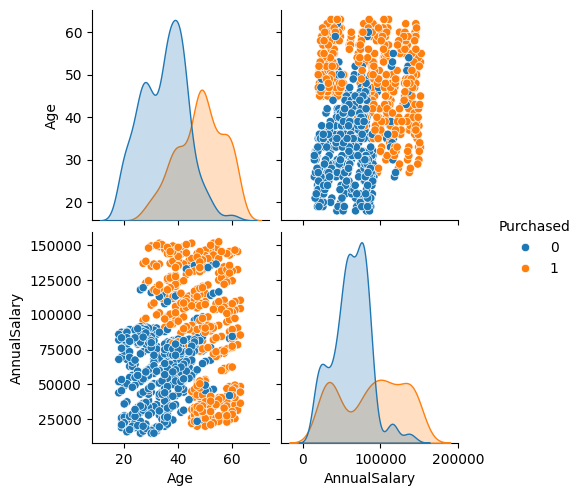

In [9]:
# entendendo a distribuição das variáveis 'Age' e 'AnnualSalary'
sns.pairplot(df, vars=['Age', 'AnnualSalary'], hue='Purchased')

#### nesse dataset, muitos indivíduos possuem alta renda anual, representando comportamento fianceiro real, e portanto, não devem ser removidos da base.

#### será aplicada transformação logarítmica na variável para ajudar o primeiro modelo baseline de regressão logística que é mais sensível à outliers, embora o modelo XGBoost, 

#### que também será treinado nesse projeto, performe bem  mesmo com valores extremos.

#### a variável 'Age' também apresenta distribuição coerente com a realidade, com indivíduos de 18 a 63 anos.

## **Análise da distribuição da variável Target**

Purchased
0    598
1    402
Name: count, dtype: int64
---------------------------------------------
Purchased
0    0.598
1    0.402
Name: proportion, dtype: float64
---------------------------------------------


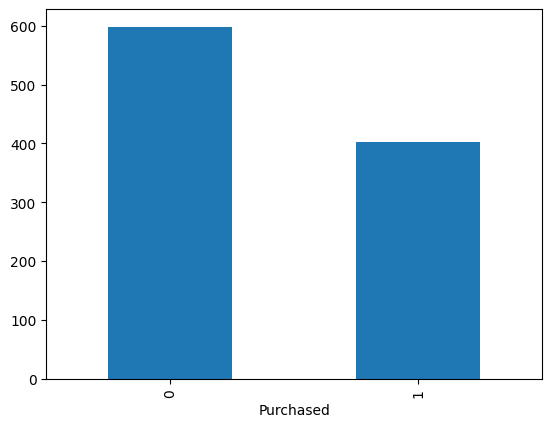

In [10]:
print(df['Purchased'].value_counts())
print('---' * 15)
print(df['Purchased'].value_counts(normalize=True))
print('---' * 15)
df['Purchased'].value_counts().plot(kind='bar')
plt.show()

#### A variável target apresenta um moderado desbalaceamento, sendo a classe minoritária que o modelo deverá prever,

#### não compradores: ~60% da base,

#### compradores: ~40% da base,

#### indicando necessidade de trazer técnicas de estratificação na divisão das bases e/ou balanceamento antes de modelagem.

# **Matriz de correlação**

## Análise de correlação linear com a variável Target

In [11]:
corr = df.corr()

corr['Purchased'].sort_values(ascending=False)

Purchased       1.000000
Age             0.616036
AnnualSalary    0.364974
Gender         -0.047211
Name: Purchased, dtype: float64

#### a análise inicial mostrou correlação positiva forte da variável 'Age' com a variável target de ~61%

#### indicando que indivíduos mais maduros são mais propensos a comprar veículos, mais do que indivíduos com renda anual maior (AnnualSalary), 

#### que apresenta correlação fraca com a variável target de ~36%

#### variável 'Gender' apresentou correlação linear fraca, mas deve permanecer no projeto, pois pode ser detectada alguma correlação não linear que seja importante para o modelo.

## **Análise bivariada (idade x compradores)**

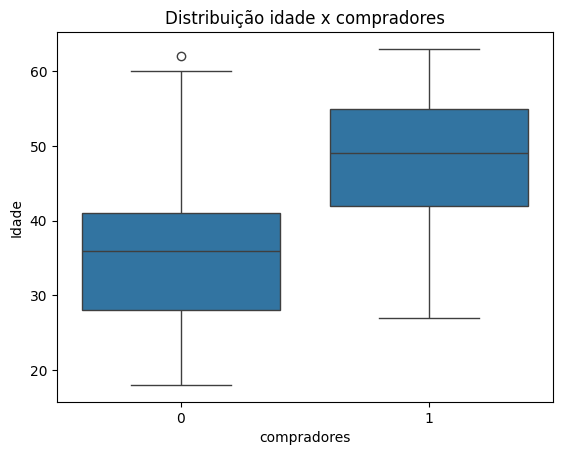

In [12]:
sns.boxplot(
    df,
    x='Purchased',
    y='Age'
)

plt.title('Distribuição idade x compradores')
plt.xlabel('compradores')
plt.ylabel('Idade')

plt.show()

#### A variável 'Age' se confirma como boa preditora para o modelo, separando bem as classes.

#### A análise mostra uma distribuição de indivíduos compradores mais maduros, com mediana de ~50 anos

#### enquanto não compradores são indivíduos mais jovens, com mediana de ~36 anos.

## **Análise bivariada (salário anual x compradores)**

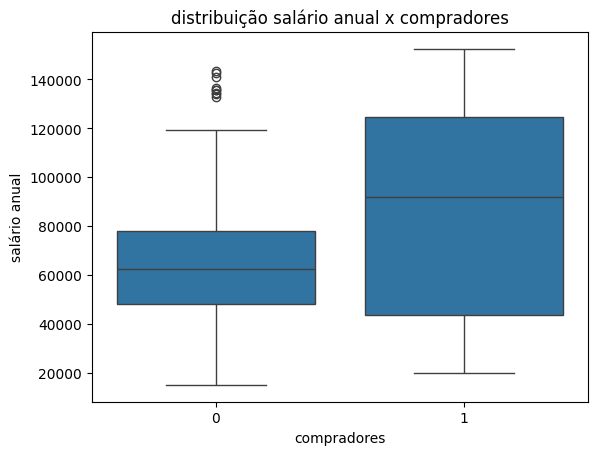

In [13]:
sns.boxplot(
    df,
    x='Purchased',
    y='AnnualSalary'
)

plt.title('distribuição salário anual x compradores')
plt.xlabel('compradores')
plt.ylabel('salário anual')

plt.show()

#### A análise mostra que há compradores e não compradores com diversas rendas anuais,

#### mas há sim uma renda mediana maior de ~90.000 em clientes que compram,

#### e uma renda mediana menor de ~65.000 em clientes que não compraram.

## **Análise de correlação entre as variáveis**

#### nessa etapa será analisado como se comporta a correlação linear das variáveis entre si, investigando possíveis problemas de multicolinearidade que possam prejudicar o modelo,

#### embora XGBoost também lide bem com problemas de multicolinearidade.

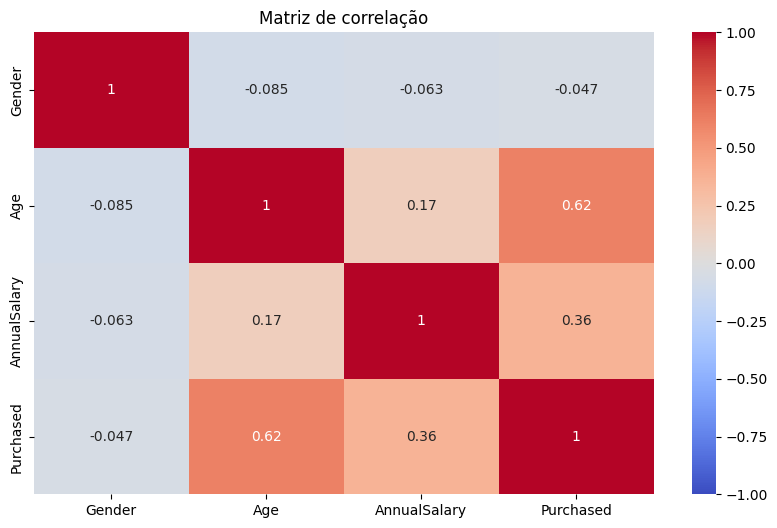

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(
    corr, 
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('Matriz de correlação')
#plt.savefig("E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\PROJETO_M392\IMAGENS/matriz_correlação.png")
#df.to_csv("E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\PROJETO_M392\BASE\PROCESSADA\carros_clientes_processed.csv", index=False)
plt.show()

#### a base não apresenta variáveis correlacionadas entre si, não sendo necessário nenhum tratamento de multicolinearidade nessa etapa.

## **Conclusõs iniciais** 

#### Os valores extremos presentes na variável 'AnnualSalary' representam rendas reais de indivíduos da base e permanecerão para a etapa de modelagem do modelo final, porém será realizada técnica de transformação logaritmica 

#### na variável, ajudando o primeiro modelo baseline de regressão logística que é mais sensível à valores extremos.

#### A variável 'Gender' foi transformada de categórica para numérica para uma melhor análise de possíveis variáveis candidatas para o modelo e embora não tenha apresentado correlação linear significativa, deve permanecer para 

#### que o modelo decida a importância de cada variável.

#### A base apresenta problemas de desbalanceamento de classes, indicando que avaliar o modelo apenas com métrica de acurácia não é a melhor escolha. 

#### será aplicada estratificação no processo de divisão dos dados e avaliadas técnicas de balanceamento, caso necessário.

#### A variável target apresentou correlação forte com a variável 'Age' que deve se manter como uma das mais importantes para o modelo.

# **Pré-modelagem**

## **Divisão da base**

#### nessa etapa, dividiremos as bases de treinamento e teste do modelo antes de qualquer transformação para evitar data leakage.

In [15]:
from src.data.split_data import split_data

X_train, X_test, y_train, y_test = split_data(df, 'Purchased')

## **Transformação logarítmica na variável 'AnnualSalary' +**

## **Escalonamento das Variáveis**

#### Essa etapa de transformação logarítmica faz-se necessária para o treinamento do modelo baseline de Regressão logística que é mais sensível a outliers,

#### e será feita também a técnica de escalonamento das variáveis para garantir maior eficiência no modelo.

In [16]:
from src.features.preprocessing import preprocess_data

X_train, X_test = preprocess_data(X_train, X_test)

In [17]:
X_train.head()

,Gender,Age,AnnualSalary_log
790,1,-1.207112,0.585497
488,1,1.105363,-1.796534
616,1,1.845356,-0.792442
479,0,-0.559619,1.075891
84,0,1.752857,0.312385


## **Treinamento do 1° modelo - LogisticRegression**

In [18]:
from src.models.train_baseline import train_baseline_model

model_log, scores_log = train_baseline_model(X_train, y_train)

ROC AUC em cada subconjunto:
[0.9  0.88 0.88 0.9  0.87]
Média ROC AUC: 0.8862
Desvio padrão: 0.0119


#### O primeiro modelo apresentou ROC AUC média de ~0.88, indicando que ele tem ~88% de chance de classificar corretamente um dado novo.

#### com aplicação de cross validation, o modelo apresentou métricas estáveis em cada fold, com desvio padrão baixissimo de ~0.01, e, portanto, não está sofrendo overfitting.

#### variando ROC AUC de 0.87 a 0.90 da pior a melhor performance.

## **Treinamento do 2° modelo - XGBoost**

#### nessa etapa serão usadas as mesmas bases do treinamento do baseline para uma justa avaliação dos algoritmos, embora o modelo XGBoost Classifier não precise que as bases estejam escalonadas nem seja sensível à outliers.

In [19]:
from src.models.train_xgboost import train_xgboost_model

model_xgb, scores_xgb = train_xgboost_model(X_train, y_train)

ROC AUC em cada subconjunto:
[0.97 0.96 0.94 0.97 0.95]
Média ROC AUC: 0.9577
Desvio padrão: 0.0109


## **Comparação de resultados**

                Modelo  ROC AUC média  Desvio padrão
1              XGBoost       0.957684       0.010877
0  Regressão Logística       0.886182       0.011942


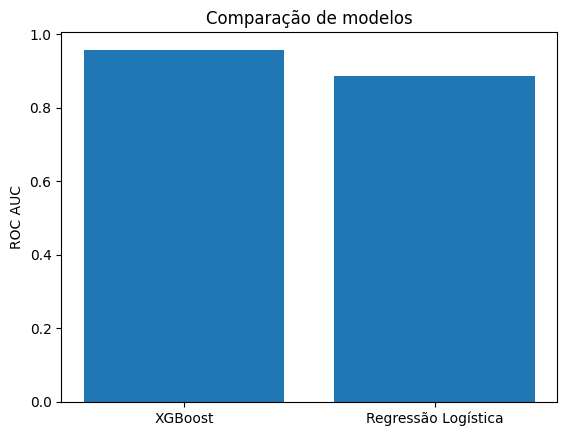

In [20]:
from src.models.compare_models import compare_models

df_result = compare_models(scores_log, scores_xgb)

#### O XGboost apresentou robustez com ROC AUC média de ~0.95, alta de 7 pontos percentuais se comparado ao modelo de Regressão Logística, 

#### o Xgboost apresenta alta capacidade de discriminação entre classes, indicando forte separabilidade entre compradores e não compradores.

#### com aplicação de cross validation, o modelo apresentou performance consistentemente alta em todos os subconjuntos, com desvio padrão muito baixo de ~0.01, e, portanto, 

#### O modelo apresentou baixa variabilidade entre os folds, indicando estabilidade na performance.

#### variando ROC AUC de 0.94 a 0.97 da pior a melhor performance.

#### o modelo escolhido, portanto, para as próximas etapas será o XGBoost por sua performance nos dados de treino. 

#### Será aplicado no modelo ajustes de hiperparâmetros a fim de extrair um pouco mais de performance e garantir que o modelo esteja performando da forma mais otimizada possível.

# **Ajustes de hiperparâmetros**

### **técnica: randomizedsearchCV**

In [21]:
from src.models.tune_xgb import tune_xgboost_model

best_model, best_params = tune_xgboost_model(X_train, y_train)

Melhores parâmetros:
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 600, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


#### **subsample = 0.6** indica que o modelo usa 60% dos dados do dataset em cada árvore.

#### **reg_lambda = 1** penaliza pesos muito grandes.

#### **reg_alpha = 0.1** força o modelo a simplificar.

#### **Learning_rate = 0.01** é uma estratégia comum para evitar overfitting, o modelo faz passos pequenos em direção à solução ótima,

#### isso geralmente leva a um modelo mais preciso, mas requer mais árvores para convergir.

#### **n_estimators = 600**, randomized search CV determinou 600 árvores de decisão, pois com uma taxa de aprendizado de 0.01, o modelo precisa de mais árvores para aprender as complexidades dos dados.

#### **max_depth = 5** limita a profundidade e evita que as árvores memorizem os dados de treinamento.

#### **colsample_bytree=1.0** usa todas as variáveis.

#### Nas próximas etapas se realizará o teste do modelo ajustado com dados novos para medir sua capacidade de generalização.

# **Treino e Teste final do XGBoost Classifier**

#### Além de aplicar o teste final, também será aplicada a transformação das probabilidades nas previsões binárias, que oferecem diferentes perspectivas sobre as previsões feitas pelo modelo,

#### retornando as probabilidades associadas a cada classe para as instâncias do conjunto de teste. 

#### Para cada amostra, retorna um array de probabilidades, onde cada valor indica a probabilidade de a amostra pertencer a cada classe.

In [22]:
# treino final
best_model.fit(X_train, y_train)

# teste final
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]     #probabilidades da classe 1

## **Distribuição das probabilidades**

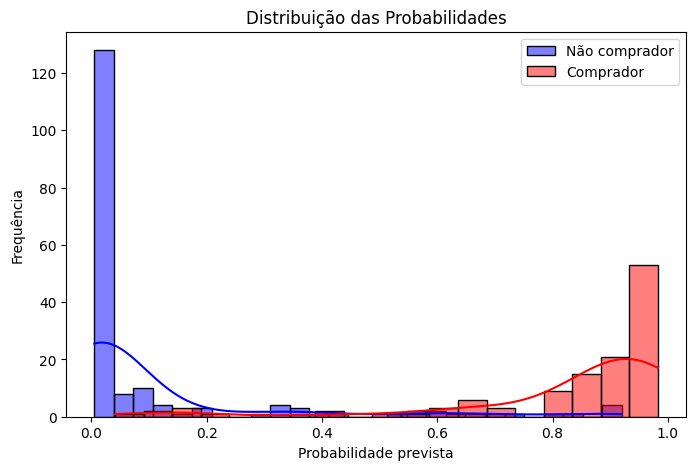

In [23]:
# separar por classe real
proba_0 = y_prob[y_test == 0]
proba_1 = y_prob[y_test == 1]

plt.figure(figsize=(8,5))

sns.histplot(proba_0, color='blue', label='Não comprador', kde=True)
sns.histplot(proba_1, color='red', label='Comprador', kde=True)

plt.xlabel('Probabilidade prevista')
plt.ylabel('Frequência')
plt.title('Distribuição das Probabilidades')
plt.legend()
#plt.savefig("E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\PROJETO_M392\IMAGENS\distribuição_prob.png")
plt.show()

#### é possível notar que o modelo separa bem as classes, com os não compradores proximos de 0

#### e os compradores próximos de 1

In [28]:
print(f"métrica AUC-ROC:\n {roc_auc_score(y_test,y_prob):.2f}")
print('---' * 25)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")
print('---' * 25)
print(f'Relatório de Classificação:\n {classification_report(y_test, y_pred)}')

métrica AUC-ROC:
 0.97
---------------------------------------------------------------------------
Acurácia: 0.92
---------------------------------------------------------------------------
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.94      0.92      0.93       179
           1       0.88      0.92      0.90       121

    accuracy                           0.92       300
   macro avg       0.91      0.92      0.91       300
weighted avg       0.92      0.92      0.92       300



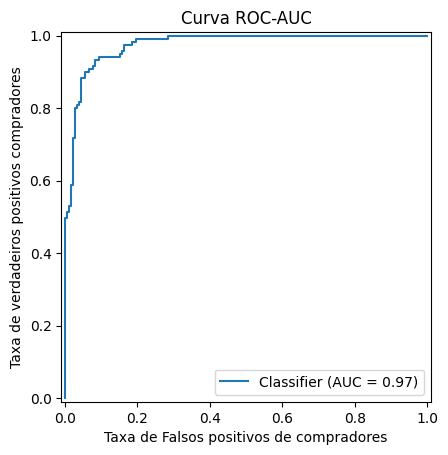

In [25]:
RocCurveDisplay.from_predictions(y_test,y_prob)

plt.title("Curva ROC-AUC")
plt.xlabel('Taxa de Falsos positivos de compradores')
plt.ylabel('Taxa de verdadeiros positivos compradores')
#plt.savefig("E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\PROJETO_M392\IMAGENS\curva_roc_auc.png")
plt.show()

#### o modelo apresentou excelente capacidade de discriminar bem as classes, com ROC-AUC de ~97% e acurácia de ~92%.

#### Precision de 0.88, indica que dos indivíduos que o modelo previu que compraria um veículo, 88% realmente compraram.

#### Recall de 0.92, indica que dos indivíduos que realmente compraram um veículo, o modelo acertou 92% desses clientes. 

#### **A métrica recall se destaca como a métrica principal, pois a prioridade é que o algoritimo detecte o máximo de indivíduos propensos a comprar veículos.**

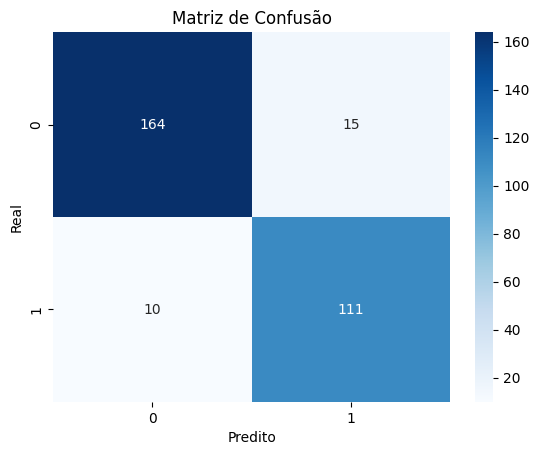

In [ ]:
# matriz de confusão

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
#plt.savefig("E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\PROJETO_M392\IMAGENS\matriz_confusão.png")
plt.show()

#### detalhando os números, temos:

#### **Verdadeiros positivos (TP) = 111**, o modelo previu 111 compradores de um total de 121 reais compradores.

#### **Falsos positivos (FP) = 15**, o modelo errou 15 não compradores, marcando-os como compradores.

#### **Verdadeiros negativos (TN) = 164**, indica que 179 não compradores, o modelo acertou 164 não compradores.

#### **Falsos negativos (FN) = 10**, o modelo errou 10 indivíduos compradores, marcando-os como não compradores.

### Falsos negativos são os erros mais críticos nesse cenário.

# **Interpretação do modelo**

### **técnica: feature_importances**

#### A importância das variáveis auxilia na interpretabilidade geral (global) dos resultados do algoritmo.

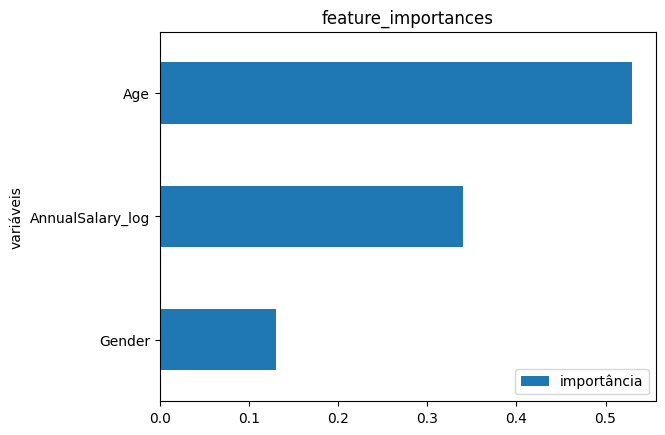

In [27]:
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'variáveis': X_train.columns,
    'importância': importance
}).sort_values(by='importância', ascending=False)

feature_importance.plot(
    x= 'variáveis',
    y= 'importância',
    kind='barh'
)

plt.gca().invert_yaxis()
plt.title("feature_importances")
#plt.savefig("E:\MAYLSON - CIENCIAS DE DADOS\Ciencia de Dados\PROJETO_M392\IMAGENS\importances.png")
plt.show()

## **Conclusões finais**

#### o modelo final XGboost apresentou ótima capacidade de separação entre compradores e não compradores, com métrica ROC AUC de 97%

#### O modelo utiliza uma taxa de aprendizado baixa combinada com um número elevado de estimadores, permitindo aprendizado gradual e mais robusto.

#### Além disso, técnicas de regularização e amostragem parcial dos dados (subsample) ajudam a reduzir overfitting, 

#### enquanto a profundidade controlada das árvores mantém um bom equilíbrio entre viés e variância.

#### uma métrica importante para o negócio e que mostra a capacidade do modelo de detectar reais compradores: recall de 92%

#### demonstra que o modelo consegue identificar a grande maioria dos clientes com potencial de compra.

#### Por outro lado, a precisão de 0.88 indica que ainda há uma pequena proporção de falsos positivos, 

#### o que pode gerar esforço adicional para o time comercial.

#### Esse trade-off é aceitável no contexto de negócio, onde é preferível abordar mais leads com potencial 

#### do que perder oportunidades de venda.

#### analisando globalmente, a feature mais importante para o modelo permanece "Age", a variável que indicou 

#### maior correlação positiva na matriz de correlação linear,

#### o modelo considera que quanto maior a idade dos indivíduos, mais propensos a comprar veículos.

## **Próximos passos**

#### - Ajuste no threshold, diminuindo o limiar para o modelo ficar mais sensível em detectar reais compradores.

#### - treinar o modelo com a técnica de early stopping, que evita overfitting, pois isso para o treino se a perda parar de diminuir.

#### - SHAP values, técnica avançada para interpretação local dos indivíduos e medição das importâncias das variáveis para o modelo.

#### - deploy do modelo

#### - monitoramento de drift